In [1]:
import findspark
findspark.init()

In [2]:
from pyspark.sql import SparkSession

In [3]:
spark = SparkSession.builder.master("local[3]").appName("code1").getOrCreate()

In [4]:
spark

In [5]:
df = spark.read.format('parquet').load(r'C:\Users\Krishna\data\accounts_parquet\accounts_parquet')

In [6]:
df.count()


97320

In [7]:
df.printSchema()

root
 |-- acct_num: integer (nullable = true)
 |-- acct_create_dt: long (nullable = true)
 |-- acct_close_dt: long (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zipcode: string (nullable = true)
 |-- phone_number: string (nullable = true)
 |-- created: long (nullable = true)
 |-- modified: long (nullable = true)



In [8]:
cntPerState = df.groupBy("state").count()

In [9]:
cntPerState.show()

+-----+-----+
|state|count|
+-----+-----+
|   AZ| 8614|
|   OR|10166|
|   NV| 8093|
|   CA|70447|
+-----+-----+



In [10]:
cntPerStatePerCity = df.groupBy("state","city").count()

In [11]:
cntPerStatePerCity.show()

+-----+---------------+-----+
|state|           city|count|
+-----+---------------+-----+
|   CA|        Oakland| 2718|
|   CA|       Stockton| 2536|
|   AZ|      Flagstaff|  804|
|   CA|     Long Beach| 3380|
|   NV|      Las Vegas| 3066|
|   AZ|        Phoenix| 3142|
|   OR|         Eugene| 1162|
|   CA|       Torrance| 1071|
|   CA|North Hollywood| 1126|
|   CA|       San Jose| 2550|
|   CA|      Palo Alto| 1372|
|   CA|       Richmond| 1361|
|   AZ|        Kingman|  795|
|   CA|       Alhambra| 1106|
|   NV|            Ely|  987|
|   CA|         Fresno| 3342|
|   CA|       Berkeley| 1310|
|   CA|     Marysville| 1292|
|   NV|           Elko| 1001|
|   CA|         Oxnard| 1145|
+-----+---------------+-----+
only showing top 20 rows



In [12]:
topCityCustomer = cntPerStatePerCity.orderBy(cntPerStatePerCity["count"].desc()).limit(10)

In [13]:
topCityCustomer.show()

+-----+-------------+-----+
|state|         city|count|
+-----+-------------+-----+
|   CA|   Sacramento| 5318|
|   CA|    San Diego| 3478|
|   OR|     Portland| 3432|
|   CA|   Long Beach| 3380|
|   CA|       Fresno| 3342|
|   AZ|      Phoenix| 3142|
|   NV|    Las Vegas| 3066|
|   CA|      Oakland| 2718|
|   CA|San Francisco| 2620|
|   CA|   Santa Rosa| 2555|
+-----+-------------+-----+



In [14]:
import matplotlib.pylab as plt

In [15]:
import pandas as pd

In [16]:
pythondf = cntPerStatePerCity.toPandas()

In [17]:
type(cntPerStatePerCity)

pyspark.sql.dataframe.DataFrame

In [18]:
type(pythondf)

pandas.core.frame.DataFrame

<AxesSubplot:xlabel='city'>

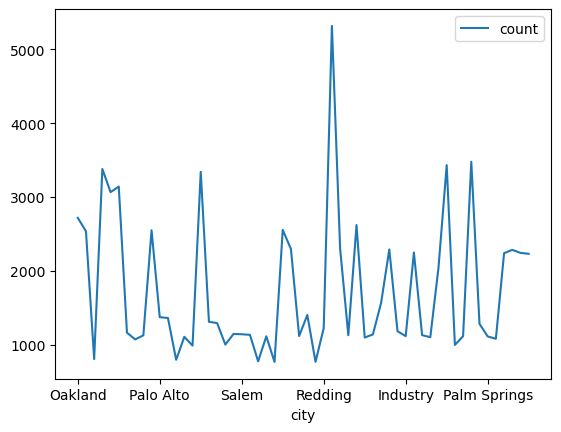

In [19]:
pythondf.plot(x="city",y="count")

<AxesSubplot:ylabel='count'>

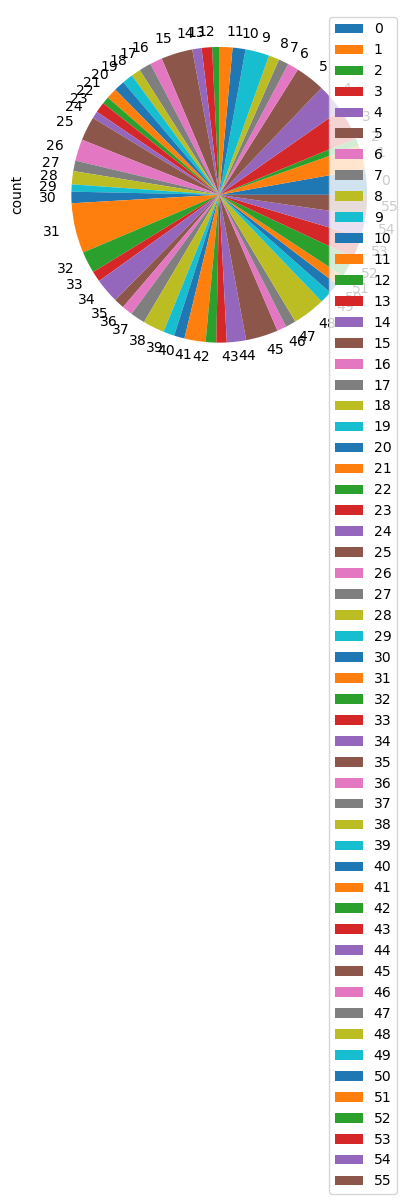

In [20]:
pythondf.plot(x="city",y="count",kind = 'pie')

<AxesSubplot:ylabel='city'>

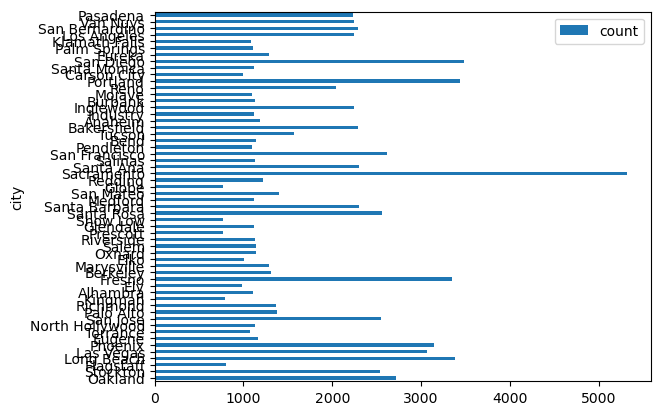

In [22]:
pythondf.plot(x="city",y="count",kind='barh')

<AxesSubplot:ylabel='Frequency'>

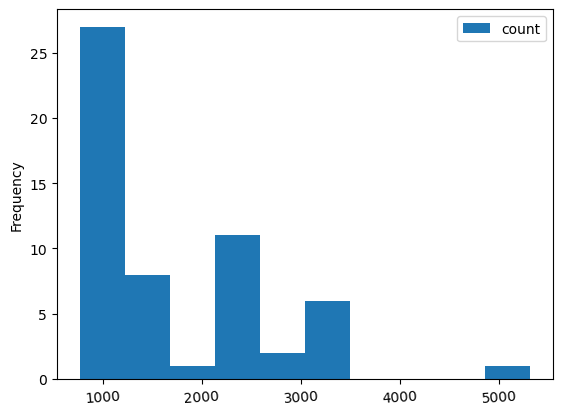

In [25]:
pythondf.plot(x="city",y="count",kind='hist')

In [26]:
pythonTop = topCityCustomer.toPandas()

<AxesSubplot:ylabel='count'>

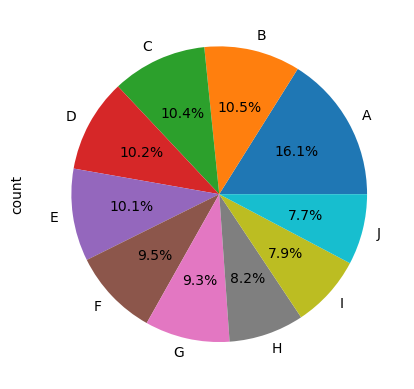

In [33]:
pythonTop.plot(x="city",y="count",kind="pie",labels=['A','B','C','D','E','F','G','H','I','J'],legend=False,autopct='%1.1f%%')

<AxesSubplot:xlabel='city'>

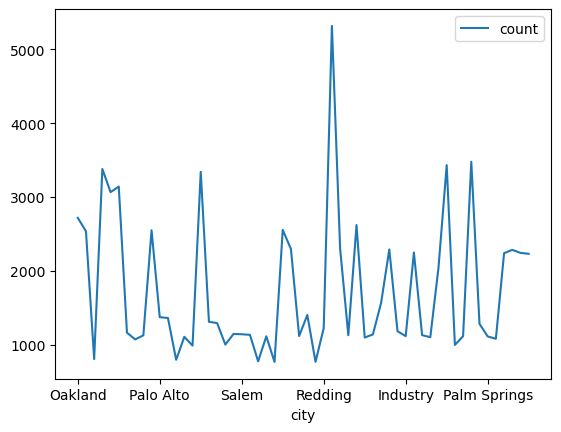

In [35]:
pythondf.plot(x="city",y="count",kind = 'line')

In [37]:
emp = spark.read.format('csv').option('header',True).option('inferSchema',True).load(r'C:\Users\Krishna\data\spark_python_code\data_for_stream\streaming_data\employee.csv')


In [38]:
emp.printSchema()

root
 |-- employee_id: integer (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- email: string (nullable = true)
 |-- phone_number: string (nullable = true)
 |-- hire_date: date (nullable = true)
 |-- job_id: string (nullable = true)
 |-- salary: double (nullable = true)
 |-- commission_pct: double (nullable = true)
 |-- manager_id: integer (nullable = true)
 |-- department_id: integer (nullable = true)



In [39]:
employees = emp.toPandas()

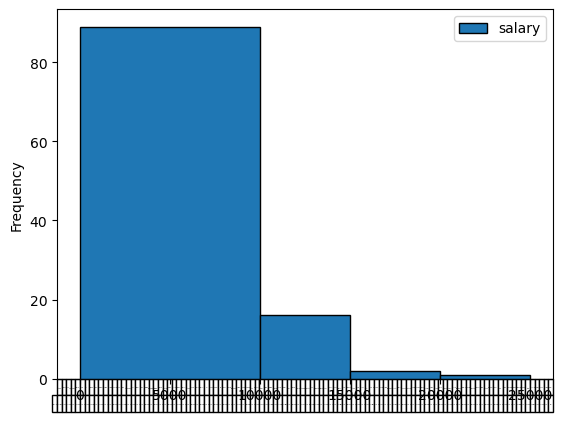

In [52]:
employees.plot(x="first_name",y=["salary"],kind='hist',bins=[0,10000,15000,20000,25000],edgecolor='black',table=True)
plt.savefig(r'C:\Users\Krishna\data\spark_python_code\emp.jpg')